## Title: Kapitza Pendulum
## Description: The balacing of inverted pendulum is done by moving the pivot point sinusoidally and this kapitza pendulum is the foundation of non linear control theory
## Contact: vinothdhanavel2503@gmail.com

In [1]:
from sympy import *
from sympy.physics.mechanics import *
init_vprinting()

In [2]:
## declare the symbols
m,g,l,a,w,b,t= symbols('m,g,l,a,w,b,t')

## dynamic symbols
theta=dynamicsymbols("theta")

## position
x= l*sin(theta)
y= l*cos(theta) + a*cos(w*t)

## time derivatives
theta_dot=diff(theta,t)
theta_ddot=diff(theta,t,2)
x_dot=diff(x,t)
y_dot=diff(y,t)

## define Lagrangian
T=0.5*m*(x_dot**2 + y_dot**2)
V=m*g*y
L=T-V

## solve
eq1=diff(diff(L,theta_dot),t) - diff(L,theta) + b*theta_dot
soln= solve(eq1, theta_ddot)[0]

## matrix rep
F= Matrix([theta_dot,soln])
f=simplify(F)
q= Matrix([theta,theta_dot])
q_dot=diff(q,t)

Eq(q_dot,f)

      ⎡                   θ̇                   ⎤
      ⎢                                       ⎥
⎡θ̇⎤   ⎢           ⎛     2             ⎞       ⎥
⎢ ⎥ = ⎢-b⋅θ̇ + l⋅m⋅⎝- a⋅w ⋅cos(t⋅w) + g⎠⋅sin(θ)⎥
⎣θ̈⎦   ⎢───────────────────────────────────────⎥
      ⎢                  2                    ⎥
      ⎣                 l ⋅m                  ⎦

In [3]:
g=f.subs({theta:'theta',theta_dot:'theta_dot'})
for i in range(2):
    print("f[{}]={}".format(i,g[i]))

f[0]=theta_dot
f[1]=(-b*theta_dot + l*m*(-a*w**2*cos(t*w) + g)*sin(theta))/(l**2*m)


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/scipy/integrate/_ivp/ivp.py:621: UserWarning: The following arguments have no effect for a chosen solver: `teval`.
  solver = method(fun, t0, y0, tf, vectorized=vectorized, **options)


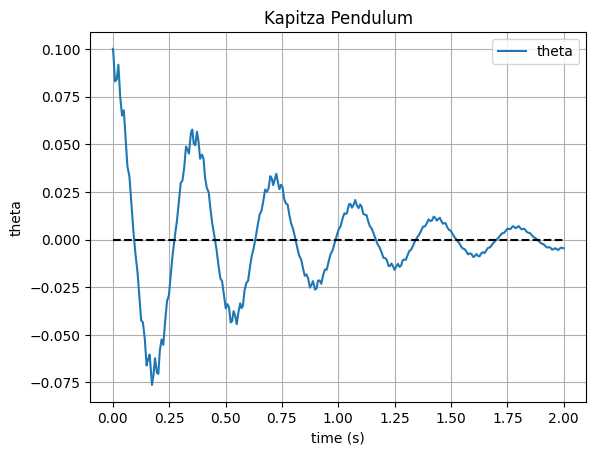

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

## declare the constants
m=1
g=9.81
l=1
a=0.1
w=2*np.pi*40
b=3

## initial conditions
x0=np.array([0.1,0])

def Kapitza_ode(t,y):
    theta=y[0]
    theta_dot=y[1]
    return (theta_dot,(-b*theta_dot + l*m*(-a*w**2*cos(t*w) + g)*sin(theta))/(l**2*m))

# solve the ode
tfinal=2
slowmo=20
frame_rate=30*slowmo
soln=solve_ivp(Kapitza_ode,[0,tfinal],x0,teval=np.linspace(0,tfinal,tfinal*frame_rate))
##output of solver
theta= soln.y[0]
t= soln.t

##plot theta
plt.plot(t,theta,label="theta")
plt.legend()
plt.grid()
plt.xlabel("time (s)")
plt.ylabel("theta")
plt.title("Kapitza Pendulum")
plt.plot(t,np.zeros_like(t),'k--')
plt.show()

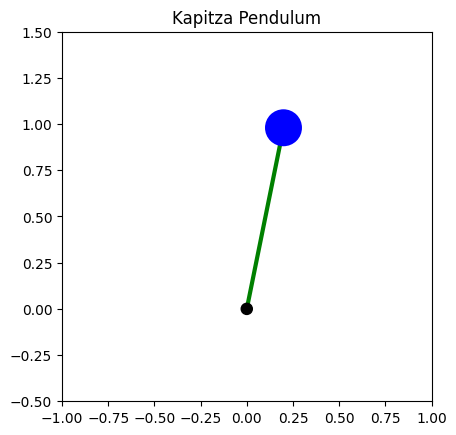

In [5]:
## create an image
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

fig=plt.figure()
ax=fig.add_subplot(aspect="equal")
ax.set_xlim(-1,1)
ax.set_ylim(-0.5,1.5)

## state to visulaize
theta=0.2
t=0
a=0.1

## mass position 
px=l*np.sin(theta)
py=l*np.cos(theta) + a*np.sin(w*t) 
circle=ax.add_patch(plt.Circle((px,py),0.1,fc="b",zorder=3))
pivot=ax.add_patch(plt.Circle((0,a*np.sin(w*t)),0.03,color="k",zorder=3))

## stick
stick=Line2D([0,px],[a*np.sin(w*t),py],color="g",linewidth=3)
ax.add_line(stick)

ax.set_title("Kapitza Pendulum")
plt.savefig("Kapitza_pendulum.png")

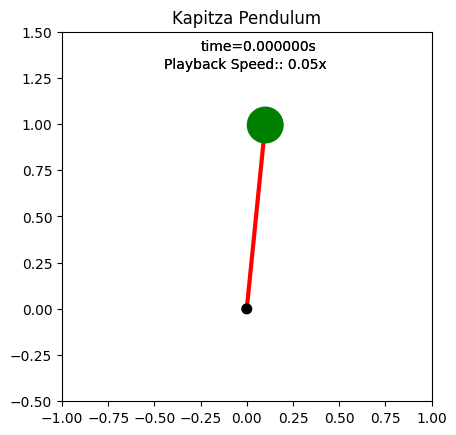

In [6]:
## Animate 
import matplotlib.animation as animation

## output of the solver
theta=soln.y[0]
t=soln.t

fig=plt.figure()
ax=fig.add_subplot(aspect="equal")
ax.set_xlim(-1,1)
ax.set_ylim(-0.5,1.5)
ax.set_title("Kapitza Pendulum")

circle=ax.add_patch(plt.Circle((0,0),0.1,fc="g",zorder=3))
stick=ax.add_line(Line2D([0,1],[0,1],color='r',linewidth=3))
pivot=ax.add_patch(plt.Circle((0,0),0.03,fc='k',zorder=3))
timestamp=ax.add_artist(plt.text(-0.25,1.4,"time=0.00s"))
ax.add_artist(plt.text(-0.45,1.3,'Playback Speed:: 0.05x '))

def animate(i):
    px=l*np.sin(theta[i])
    py=l*np.cos(theta[i]) + a*np.sin(w*t[i])
    circle.set_center((px,py))
    pivot.set_center((0,a*np.sin(w*t[i])))

    stick.set_data([0,px],[a*np.sin(w*t[i]),py])

    timestamp.set(text=f'time={t[i]:3f}s')

## save video
anim=animation.FuncAnimation(fig,animate,frames=len(t))
ffmpeg_writer=animation.FFMpegWriter(fps=30)
anim.save("Kapitza_Pendulum.mp4",writer=ffmpeg_writer)
anim.save("Kapitza_Pendulum_gif.gif",writer=ffmpeg_writer)

